# LUMINA Dataset - Exploratory Data Analysis

**Dataset**: Linguistic Unified Multimodal Indonesian Natural Audio-Visual  
**Purpose**: Comprehensive EDA for Indonesian Sentence-Level Lip Reading Research  
---

## Dataset Overview

LUMINA is a constrained audio-visual dataset featuring:
- **14 native Indonesian speakers** (9 male, 5 female)
- **~1,000 sentences per speaker** (~14,000 total)
- **Video**: 1920×1080, 25 fps, ~3.3 seconds per clip

Source: [Mendeley Data](https://data.mendeley.com/datasets/8fw93k4rny/4)

## 1. Setup and Imports

In [1]:
# Install required packages (uncomment if needed)
# !pip install opencv-python matplotlib seaborn pandas numpy tqdm

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import warnings
import re
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Dataset Path Configuration

In [2]:
# Configure your dataset path here
DATASET_PATH = "../LUMINA_Dataset/"  # Change this to your actual path

dataset_path = Path(DATASET_PATH)
male_path = dataset_path / 'male'
female_path = dataset_path / 'female'

print(f"Dataset Path: {dataset_path}")
print(f"Male Path: {male_path}")
print(f"Female Path: {female_path}")
print(f"\nMale folder exists: {male_path.exists()}")
print(f"Female folder exists: {female_path.exists()}")

Dataset Path: ../LUMINA_Dataset
Male Path: ../LUMINA_Dataset/male
Female Path: ../LUMINA_Dataset/female

Male folder exists: True
Female folder exists: True


## 3. Scan Dataset Structure

In [3]:
# Initialize data containers
video_data = []
audio_data = []

print("Scanning dataset...\n")

for gender_folder in [male_path, female_path]:
    if not gender_folder.exists():
        print(f"⚠ Warning: {gender_folder} does not exist!")
        continue
    
    gender = gender_folder.name
    
    # Check for video/audio subfolders
    video_subfolder = gender_folder / 'video'
    
    # Get video files from video subfolder (or fallback to main folder)
    if video_subfolder.exists():
        video_files = list(video_subfolder.glob('*.MP4'))
        print(f"Found {len(video_files)} videos in {gender}/video/")
    else:
        video_files = list(gender_folder.glob('*.MP4'))
        print(f"Found {len(video_files)} videos in {gender}/")
    
    # Process video files
    for video_file in tqdm(video_files, desc=f"Processing {gender}"):
        filename = video_file.name
        
        # Extract speaker ID from filename (P01, P02, etc.)
        match = re.search(r'P(\d+)', filename)
        if match:
            speaker_id = f"P{match.group(1)}"
        else:
            speaker_id = "Unknown"
        
        video_data.append({
            'speaker_id': speaker_id,
            'gender': gender,
            'filename': filename,
            'filepath': str(video_file),
            'file_size_mb': video_file.stat().st_size / (1024**2)
        })

# Create DataFrames
video_df = pd.DataFrame(video_data)

print(f"\nScan complete!")
print(f"Total videos: {len(video_df)}")

Scanning dataset...

Found 8580 videos in male/video/


Processing male:   0%|          | 0/8580 [00:00<?, ?it/s]

Found 5228 videos in female/video/


Processing female:   0%|          | 0/5228 [00:00<?, ?it/s]


Scan complete!
Total videos: 13808


## 4. Basic Statistics

In [4]:
# Speaker statistics
speaker_counts = video_df.groupby(['speaker_id', 'gender']).size().reset_index(name='count')
gender_counts = video_df['gender'].value_counts()

print("="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"\nTotal Speakers: {len(speaker_counts)}")
print(f"  - Male: {len(speaker_counts[speaker_counts['gender']=='male'])}")
print(f"  - Female: {len(speaker_counts[speaker_counts['gender']=='female'])}")
print(f"\nTotal Videos: {len(video_df)}")
print(f"  - Male: {gender_counts.get('male', 0)} ({gender_counts.get('male', 0)/len(video_df)*100:.1f}%)")
print(f"  - Female: {gender_counts.get('female', 0)} ({gender_counts.get('female', 0)/len(video_df)*100:.1f}%)")
print(f"\nVideos per Speaker:")
print(f"  - Mean: {speaker_counts['count'].mean():.0f}")
print(f"  - Std: {speaker_counts['count'].std():.0f}")
print(f"  - Min: {speaker_counts['count'].min()}")
print(f"  - Max: {speaker_counts['count'].max()}")
print(f"\nTotal Storage:")
print(f"  - Videos: {video_df['file_size_mb'].sum():.2f} MB ({video_df['file_size_mb'].sum()/1024:.2f} GB)")

DATASET STATISTICS

Total Speakers: 13
  - Male: 8
  - Female: 5

Total Videos: 13808
  - Male: 8580 (62.1%)
  - Female: 5228 (37.9%)

Videos per Speaker:
  - Mean: 1062
  - Std: 34
  - Min: 1017
  - Max: 1113

Total Storage:
  - Videos: 1613.98 MB (1.58 GB)


## 5. Analyze Video Properties

We'll sample a subset of videos to analyze their properties (resolution, fps, duration, etc.)

In [5]:
# Sample videos for detailed analysis
SAMPLE_SIZE = 100  # Adjust based on your needs
sample_videos = video_df.sample(n=min(SAMPLE_SIZE, len(video_df)), random_state=42)

video_properties = {
    'width': [],
    'height': [],
    'fps': [],
    'frame_count': [],
    'duration': []
}

print(f"Analyzing {len(sample_videos)} videos...\n")

for idx, row in tqdm(sample_videos.iterrows(), total=len(sample_videos)):
    try:
        cap = cv2.VideoCapture(row['filepath'])
        
        if cap.isOpened():
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            duration = frame_count / fps if fps > 0 else 0
            
            video_properties['width'].append(width)
            video_properties['height'].append(height)
            video_properties['fps'].append(fps)
            video_properties['frame_count'].append(frame_count)
            video_properties['duration'].append(duration)
        
        cap.release()
    except Exception as e:
        print(f"Error: {e}")

# Print statistics
print("\n" + "="*60)
print("VIDEO PROPERTIES")
print("="*60)
print(f"\nResolution: {np.mean(video_properties['width']):.0f}×{np.mean(video_properties['height']):.0f}")
print(f"\nFPS: {np.mean(video_properties['fps']):.2f} ± {np.std(video_properties['fps']):.2f}")
print(f"\nFrame Count: {np.mean(video_properties['frame_count']):.0f} ± {np.std(video_properties['frame_count']):.0f}")
print(f"\nDuration: {np.mean(video_properties['duration']):.2f} ± {np.std(video_properties['duration']):.2f} seconds")
print(f"\nEstimated Total Duration: {(len(video_df) * np.mean(video_properties['duration'])) / 3600:.2f} hours")

Analyzing 100 videos...



  0%|          | 0/100 [00:00<?, ?it/s]


VIDEO PROPERTIES

Resolution: 250×150

FPS: 25.00 ± 0.00

Frame Count: 84 ± 0

Duration: 3.34 ± 0.02 seconds

Estimated Total Duration: 12.83 hours


## 6. Visualizations

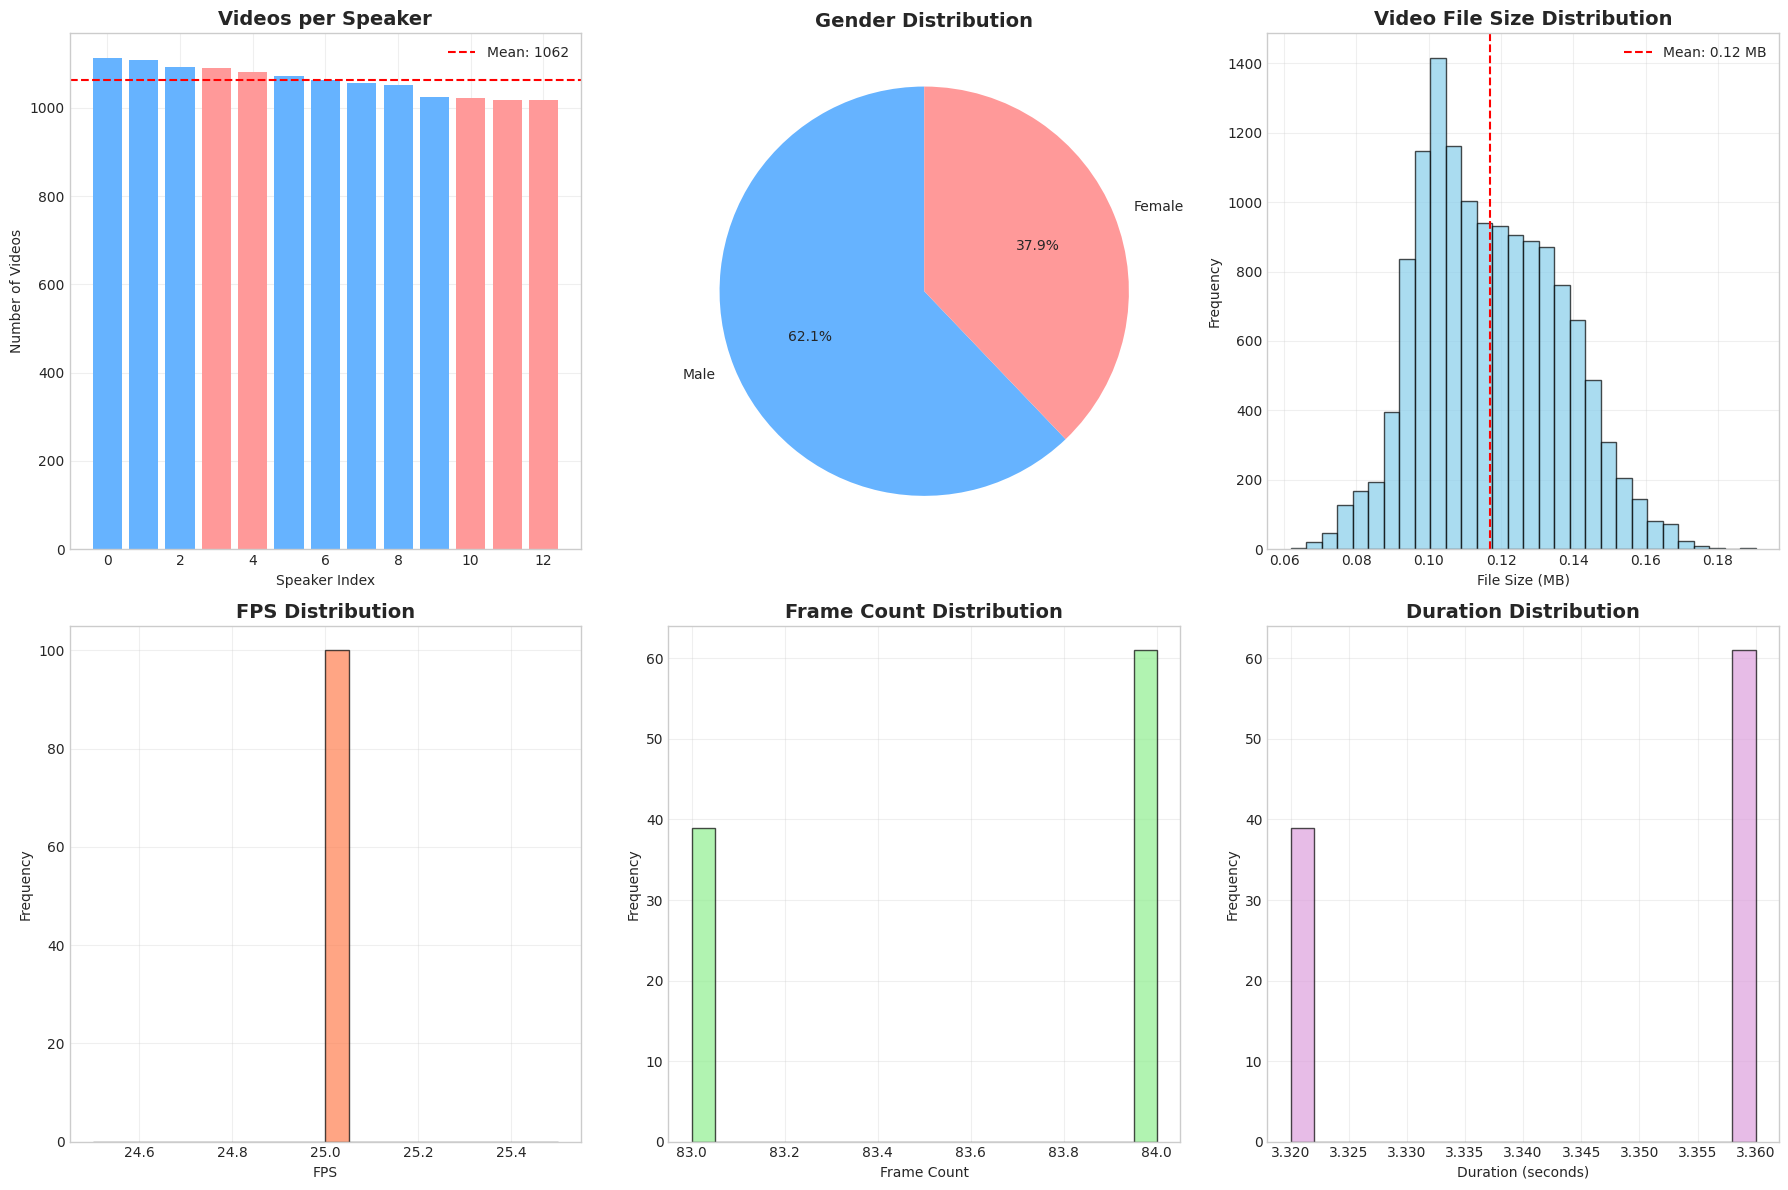

Visualization saved as 'lumina_eda_overview.png'


In [6]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Videos per speaker
speaker_data = speaker_counts.sort_values('count', ascending=False)
colors = ['#ff9999' if g == 'female' else '#66b3ff' for g in speaker_data['gender']]

axes[0, 0].bar(range(len(speaker_data)), speaker_data['count'], color=colors)
axes[0, 0].axhline(speaker_data['count'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {speaker_data["count"].mean():.0f}')
axes[0, 0].set_xlabel('Speaker Index')
axes[0, 0].set_ylabel('Number of Videos')
axes[0, 0].set_title('Videos per Speaker', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Gender distribution
axes[0, 1].pie(gender_counts.values, labels=[g.capitalize() for g in gender_counts.index], 
              autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0, 1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# 3. File size distribution
axes[0, 2].hist(video_df['file_size_mb'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(video_df['file_size_mb'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {video_df["file_size_mb"].mean():.2f} MB')
axes[0, 2].set_xlabel('File Size (MB)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Video File Size Distribution', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. FPS distribution
axes[1, 0].hist(video_properties['fps'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('FPS')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('FPS Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Frame count distribution
axes[1, 1].hist(video_properties['frame_count'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Frame Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Frame Count Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 6. Duration distribution
axes[1, 2].hist(video_properties['duration'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Duration (seconds)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Duration Distribution', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lumina_eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'lumina_eda_overview.png'")

## 7. Sample Frame Visualization

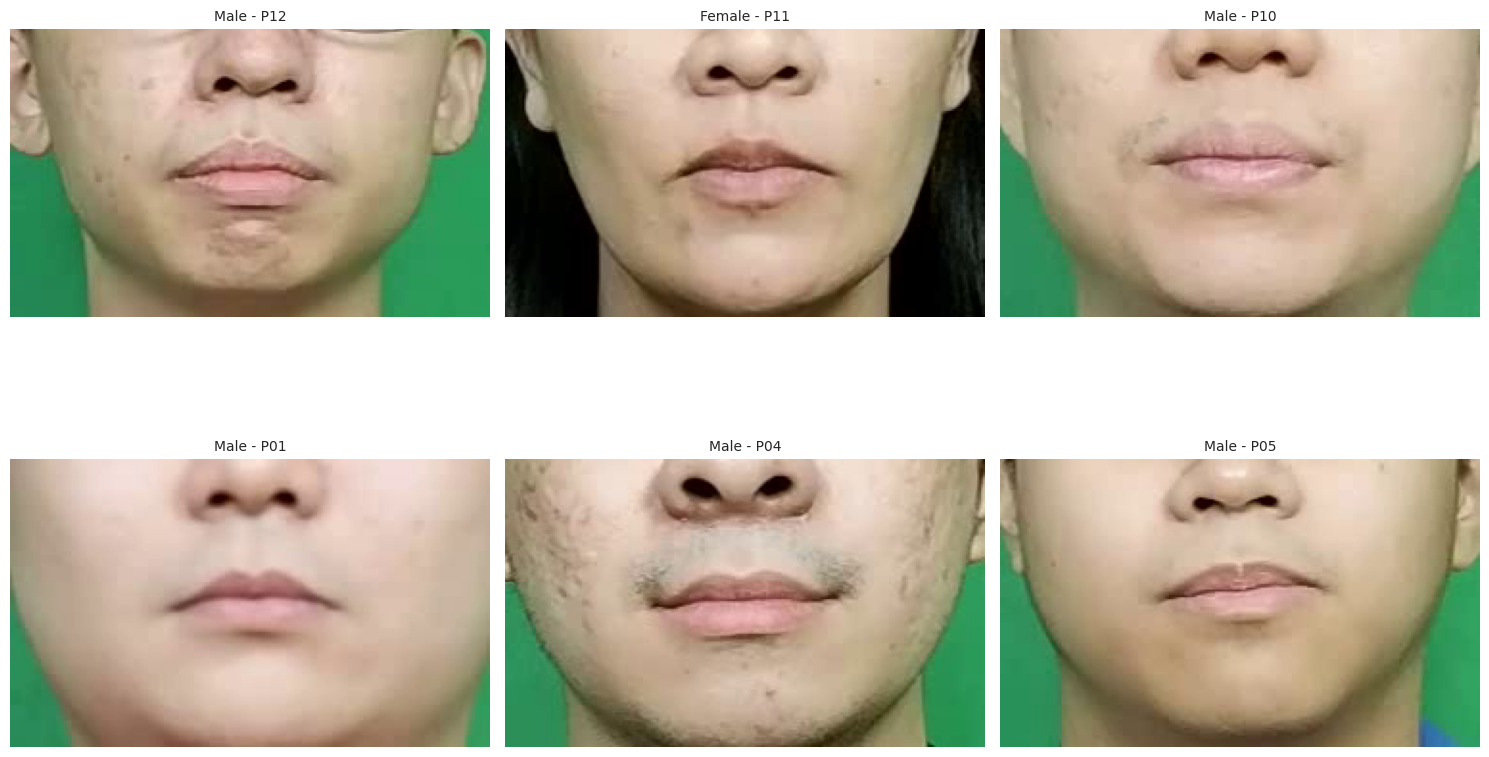

Sample frames saved as 'sample_frames.png'


In [7]:
# Visualize sample frames from random videos
sample_for_viz = video_df.sample(n=min(6, len(video_df)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (i, row) in enumerate(sample_for_viz.iterrows()):
    if idx >= 6:
        break
    
    cap = cv2.VideoCapture(row['filepath'])
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"{row['gender'].capitalize()} - {row['speaker_id']}", fontsize=10)
        axes[idx].axis('off')
    
    cap.release()

plt.tight_layout()
plt.savefig('sample_frames.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sample frames saved as 'sample_frames.png'")

## 8. Text Label Analysis (Transcription EDA)

In [9]:
# Set your path
excel_path = "../LUMINA_Dataset/list_of_sentence.xlsx"
df_labels = pd.read_excel(excel_path)

# 1. Basic Cleaning (assuming columns are 'sentence_number' and 'text')
# Use lowercase to match training logic
df_labels['clean_text'] = df_labels['Text'].astype(str).str.lower().str.strip()

# 2. Calculate Lengths
df_labels['char_count'] = df_labels['clean_text'].apply(len)
df_labels['word_count'] = df_labels['clean_text'].apply(lambda x: len(x.split()))

print(f"Total Unique Sentences: {len(df_labels)}")
print(f"Average Sentence Length: {df_labels['char_count'].mean():.2f} characters")
print(f"Max Sentence Length: {df_labels['char_count'].max()} characters")
df_labels.head()

Total Unique Sentences: 2500
Average Sentence Length: 35.08 characters
Max Sentence Length: 44 characters


,Sentence Number,Text,clean_text,char_count,word_count
0,1,cari enam fonemik hijau dari solo,cari enam fonemik hijau dari solo,33,6
1,2,cari enam suvenir indigo di opera,cari enam suvenir indigo di opera,33,6
2,3,gutik satu berewok kuning di sekolah,gutik satu berewok kuning di sekolah,36,6
3,4,cari lima mukjizat indigo ke sekolah,cari lima mukjizat indigo ke sekolah,36,6
4,5,cari sepuluh emosi hijau ke opera,cari sepuluh emosi hijau ke opera,33,6


## 9. Sentence Length Distribution

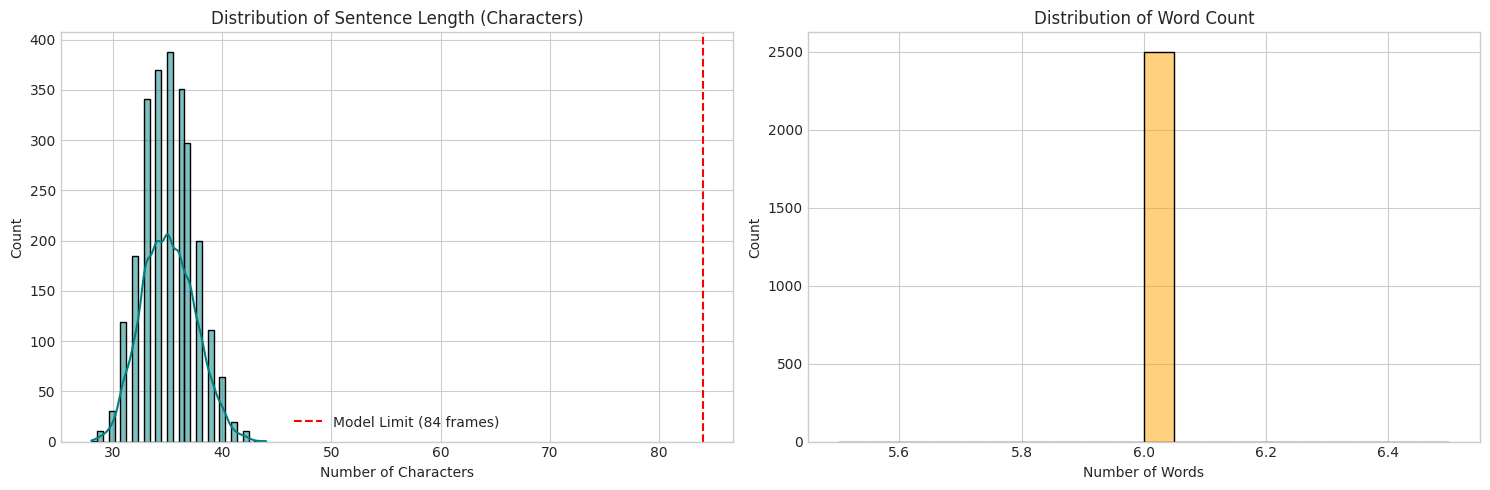

In [10]:
plt.figure(figsize=(15, 5))

# Plot Character Count Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_labels['char_count'], bins=30, kde=True, color='teal')
# Add a vertical line for your Model's Sequence Length (84)
plt.axvline(x=84, color='red', linestyle='--', label='Model Limit (84 frames)')
plt.title('Distribution of Sentence Length (Characters)')
plt.xlabel('Number of Characters')
plt.legend()

# Plot Word Count Distribution
plt.subplot(1, 2, 2)
sns.histplot(df_labels['word_count'], bins=20, kde=True, color='orange')
plt.title('Distribution of Word Count')
plt.xlabel('Number of Words')

plt.tight_layout()
plt.show()

## 10. Vocabulary and Character Analysis

Unique characters in dataset:  abcdefghijklmnoprstuvwyz


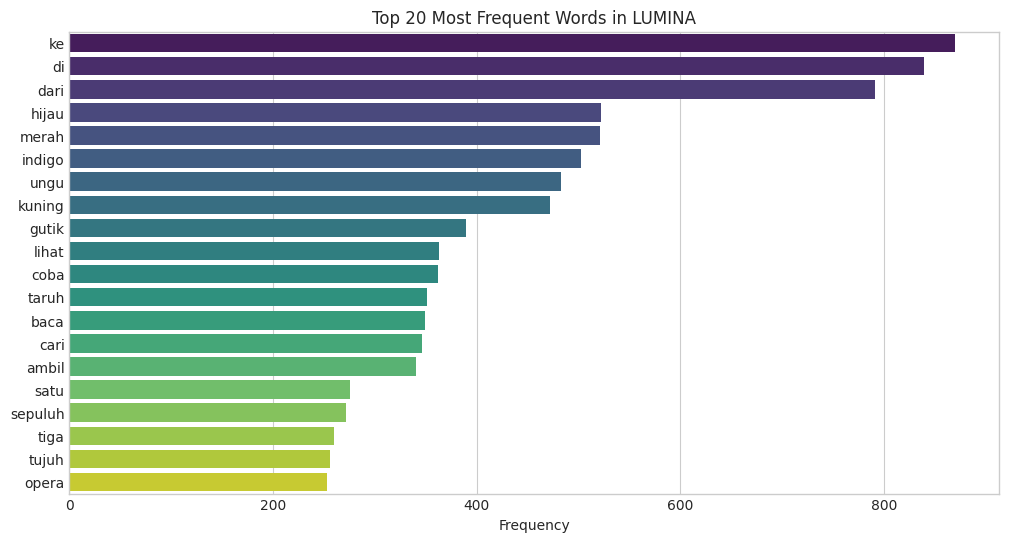

In [11]:
# 1. Most frequent words (Indonesian)
all_words = " ".join(df_labels['clean_text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

# 2. Unique character set (to verify Vocab)
all_chars = "".join(df_labels['clean_text'])
char_freq = Counter(all_chars)
unique_chars = sorted(list(char_freq.keys()))

print("Unique characters in dataset:", "".join(unique_chars))

# Plot Top Words
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Frequent Words in LUMINA')
plt.xlabel('Frequency')
plt.show()

# LUMINA Dataset — Exploratory Data Analysis Summary

## 1. Dataset Overview

The LUMINA dataset is a Bahasa Indonesia sentence-level lip reading corpus recorded under controlled conditions. It comprises **13,808 video clips** from **13 speakers** (8 male, 5 female), totaling approximately **1.58 GB** and **12.83 hours** of footage.

| Property | Value |
|---|---|
| Total Speakers | 13 (8 male, 5 female) |
| Total Videos | 13,808 |
| Total Storage | ~1.58 GB |
| Estimated Duration | ~12.83 hours |
| Videos per Speaker (mean ± std) | 1,062 ± 34 |
| Videos per Speaker (min / max) | 1,017 / 1,113 |

---

## 2. Speaker & Gender Distribution

Per-speaker video counts are highly uniform (std = 34), indicating no single speaker disproportionately dominates the dataset. This balance reduces speaker-bias risk during training and simplifies speaker-independent evaluation.

The gender split shows a mild imbalance: **62.1% male** (8,580 videos) vs. **37.9% female** (5,228 videos), reflecting the 8:5 speaker ratio. This should be accounted for when constructing train/val/test splits — speaker-level stratified partitioning is recommended to ensure female speakers are represented proportionally across all folds.

---

## 3. Video Properties

All video clips exhibit near-zero variance in every technical property, confirming the dataset was recorded under strict, reproducible conditions.

| Property | Value |
|---|---|
| Resolution | 250 × 150 px |
| FPS | 25.00 ± 0.00 |
| Frame Count | 83–84 frames |
| Duration | ~3.34 ± 0.02 seconds |
| Mean File Size | ~0.12 MB (right-skewed) |

**Implication for modeling:** The fixed temporal length (83–84 frames) allows the visual frontend — a 3D convolutional stem followed by a 2D ResNet-18 backbone (ImageNet pretrained) — to use a hardcoded input dimension without dynamic padding or truncation. The consistent 25 FPS also means no frame-rate normalization is required during preprocessing.

---

## 4. Sentence-Level Text Analysis

LUMINA is designed for **sentence-level lip reading in Bahasa Indonesia**. All sentences follow a tightly constrained command-like schema, making the corpus well-suited for end-to-end sequence-to-sequence modeling with CTC loss.

| Property | Value |
|---|---|
| Words per Sentence | 6 (uniform across all samples) |
| Character Count Range | ~28–50 characters |
| Model Frame Limit | 84 frames |

Every sentence falls well within the 84-frame model limit (no sample exceeds it), confirming that CTC blank-frame overhead will not be a limiting factor. The uniform 6-word sentence length also provides stable, fixed-length decoding targets, which benefits CTC convergence.

**Sentence schema pattern:**
```
[verb] [number/adjective] [noun] [color] [preposition] [location]
```
*Example:* `cari enam fonemik hijau dari solo` → *"search six phonemic green from solo"*

---

## 5. Vocabulary Analysis

The top 20 most frequent words reveal a structured, finite vocabulary dominated by three semantic categories:

**Prepositions (connectives):** `ke`, `di`, `dari`
> These appear in virtually every sentence, accounting for the highest raw frequencies (800–900 occurrences each). They serve as the syntactic glue of the fixed sentence schema.

**Color terms:** `hijau`, `merah`, `indigo`, `ungu`, `kuning`
> Consistently appearing as the 4th word in each sentence template, color terms form a discrete, visually distinguishable sub-vocabulary — relevant for viseme-based discrimination.

**Action verbs:** `lihat`, `coba`, `taruh`, `baca`, `cari`, `ambil`
> These occupy the sentence-initial position and share similar lip movement patterns (open vowels, bilabials), making their disambiguation a key challenge for the model.

**Numerals / Locations:** `satu`, `sepuluh`, `tiga`, `tujuh`, `opera`, `gutik`
> Numerals appear in the quantity slot; location nouns (`opera`, `gutik`) in the final slot.

The constrained vocabulary means the model can learn strong positional priors for each word slot — advantageous for the sequential Mamba → Bi-GRU temporal encoder to exploit sequential structure.

---

## 6. Implications for Model Design

| Observation | Impact on Sentence-Level Lip Reading Pipeline |
|---|---|
| Fixed 83–84 frames per clip | Hardcoded temporal dimension for the 3D stem + 2D ResNet-18 frontend; no padding required |
| Zero FPS variance | No frame-rate normalization needed at preprocessing stage |
| Exactly 6 words per sentence | Stable, short CTC target sequences; fast convergence expected |
| All sentences within 84-frame limit | CTC alignment is feasible (T ≥ L satisfied); no sequence truncation risk |
| Structured sentence schema | Sequential Mamba → Bi-GRU encoder can exploit positional token regularities |
| Mild gender imbalance (62/38) | Use speaker-stratified splits; consider reporting gender-disaggregated WER/CER in evaluation |
| Balanced per-speaker counts | Minimal risk of speaker-dominant overfitting |